In [ ]:
import numpy as np
import pandas as pd

import imageio.v2 as imageio
from pathlib import Path
import os

import matplotlib.pyplot as plt
from collections import defaultdict, Counter

from config import PathConfig

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [2]:
def show_class_counts(class_cnt: dict[str, int]) -> None:
    plt.figure(figsize=(8, 4), dpi=200)
    bars = plt.bar(class_cnt.keys(), class_cnt.values())
    plt.xlabel("Class")
    plt.ylabel("Count")
    plt.xticks(ticks=list(class_cnt.keys()), rotation=45)

    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width() / 2, height,
            f"{int(height)}",
            ha="center", va="bottom",
            fontsize=5)

    plt.tight_layout()
    plt.show()

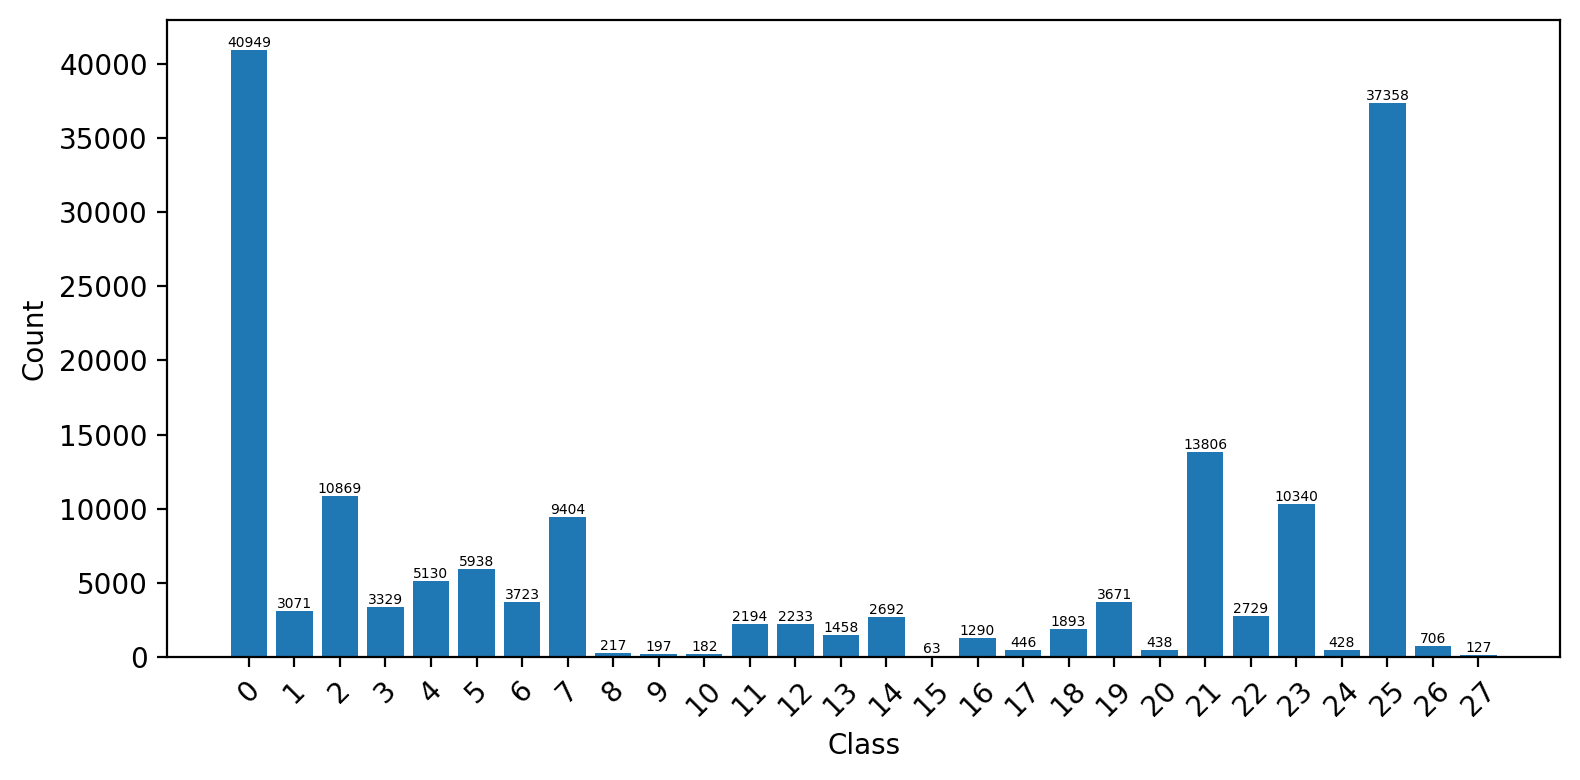


Total samples in dataset: 164881


In [5]:
train_y_df = pd.read_csv(PathConfig.train_labels_path)
external_y_df = pd.read_csv(PathConfig.external_labels_path)

y_df = pd.concat([train_y_df, external_y_df], ignore_index=True)
cls_cnt = Counter()
for target in y_df["Target"]:
    cls_cnt.update(map(int, target.split()))

show_class_counts(cls_cnt)
print(f"\nTotal samples in dataset: {sum(cls_cnt.values())}")

crazy class imbalance😿😿😿😿

In [6]:
class_labels = [
    "Nucleoplasm",
    "Nuclear membrane",
    "Nucleoli",
    "Nucleoli fibrillar center",
    "Nuclear speckles",
    "Nuclear bodies",
    "Endoplasmic reticulum",
    "Golgi apparatus",
    "Peroxisomes",
    "Endosomes",
    "Lysosomes",
    "Intermediate filaments",
    "Actin filaments",
    "Focal adhesion sites",
    "Microtubules",
    "Microtubule ends",
    "Cytokinetic bridge",
    "Mitotic spindle",
    "Microtubule organizing center",
    "Centrosome",
    "Lipid droplets",
    "Plasma membrane",
    "Cell junctions",
    "Mitochondria",
    "Aggresome",
    "Cytosol",
    "Cytoplasmic bodies",
    "Rods & ring"
]

In [14]:
def show_sample(img: np.ndarray, label_cls: str | None = None) -> None:
    """
    Visualize a single 4-channel image, showing only RGB.
    Args:
        img (np.ndarray): image of shape (H, W, 4)
        label_cls (Optional[str]): label
    """
    if img.ndim != 3 or img.shape[-1] < 3:
        raise ValueError("Expected image with shape (H, W, >=3)")

    rgb_img = img[..., :3]
    fig, ax = plt.subplots(1, 1, figsize=(4, 4))

    ax.imshow(rgb_img)
    ax.set_title(f"RGB ({label_cls or 'Unknown'})")
    ax.axis('off')

    plt.show()

In [19]:
def collect_n_samples(n: int = 3, root: Path = PathConfig.train_dir) -> dict[str, str]:
    """Collects n samples in format {sample_id: path_to_4ch_png}"""
    samples = {}

    for f in sorted(os.listdir(root)):
        if not f.endswith(".png"):
            continue

        sample_id = f.split(".")[0]
        samples[sample_id] = os.path.join(root, f)

        if len(samples) == n:
            break

    return samples

In [20]:
def show_samples(num_samples: int = 3, external: bool = False) -> None:
    samples = collect_n_samples(
        num_samples, 
        PathConfig.external_dir if external 
        else PathConfig.train_dir
    )

    for sample_id, path in samples.items():
        img = imageio.imread(path) / 255.0
        r = img[..., 0]
        g = img[..., 1]
        b = img[..., 2]
        y = img[..., 3]

        rgb = np.stack([r, g, b], axis=-1)

        label_row = y_df[y_df["Id"] == sample_id]
        label_str = None
        if not label_row.empty:
            indices = map(int, label_row["Target"].values[0].split())
            label_str = ", ".join(class_labels[idx] for idx in indices)

        show_sample(rgb, label_cls=label_str)

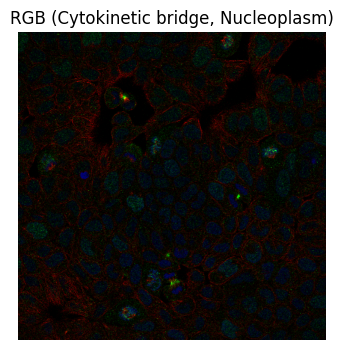

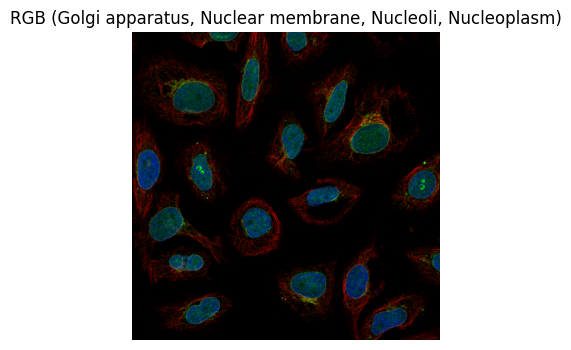

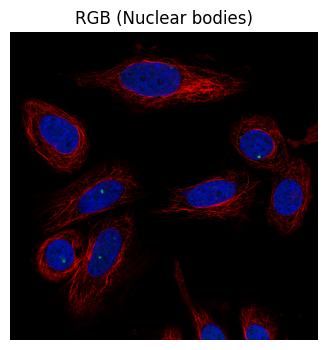

In [21]:
show_samples(3)

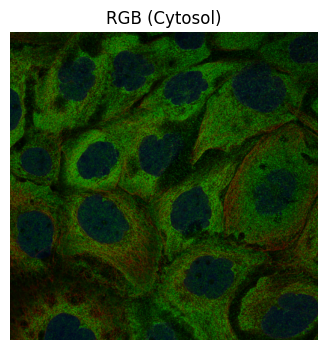

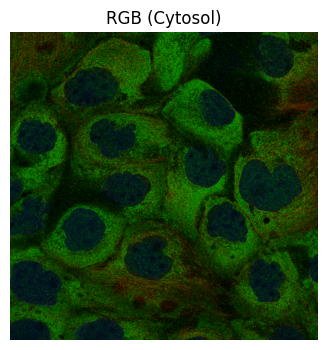

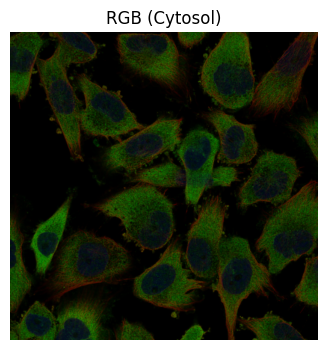

In [28]:
show_samples(3, external=True)